# Notebook 4 — Retrieval, Evaluation & Demo
**What this notebook does:** Build a FAISS index from the **test split only**, search with natural language queries, and report clean R@1/R@5/R@10/MedR metrics on data the model has never seen.

**Runtime:** T4 GPU (free tier)

**Why test split only?**
The model was trained on the train split and checkpointed based on val split loss.
Evaluating on test gives unbiased numbers — the model has never touched these videos.

**Requires from Drive:**
```
ariel/
  model.py
  model_config.json
  checkpoints/best_model.pt
  embeddings/msrvtt/test/manifest.json
  embeddings/msvd/test/manifest.json
```
---

In [1]:
!pip install -q transformers accelerate faiss-cpu tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 56.9 MB/s eta 0:00:00


## Step 1 · Mount Drive and load model

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import sys, os, json, time, torch
PROJECT   = '/content/drive/Shareddrives/DATA 298A/ariel'
EMBED_DIR = f'{PROJECT}/embeddings'

sys.path.insert(0, PROJECT)
from model import build_model

with open(f'{PROJECT}/model_config.json') as f:
    MODEL_CONFIG = json.load(f)

# Test manifests — the only split used in this notebook
TEST_MANIFESTS = [
    f'{EMBED_DIR}/msrvtt/test/manifest.json',
    f'{EMBED_DIR}/msvd/test/manifest.json',
]

os.makedirs(f'{PROJECT}/faiss_index', exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

ckpt_path = f'{PROJECT}/checkpoints/best_model.pt'
st = os.stat(ckpt_path)
ckpt = torch.load(ckpt_path, map_location='cpu')
print(f'Checkpoint path: {ckpt_path}')
print(f'Checkpoint size: {st.st_size / (1024 ** 2):.1f} MB')
print(f'Checkpoint mtime: {time.ctime(st.st_mtime)}')
print(f'Checkpoint epoch: {ckpt["epoch"]}')
print(f'Checkpoint val loss: {ckpt["val_loss"]:.4f}')

MODEL_CONFIG = ckpt.get('model_config', MODEL_CONFIG)
model, tokenizer = build_model(MODEL_CONFIG, device)
missing, unexpected = model.load_state_dict(ckpt['model_state'], strict=False)
model.eval()

missing_non_llm = [k for k in missing if not k.startswith('llm.')]
unexpected_non_llm = [k for k in unexpected if not k.startswith('llm.')]
print(f'Missing non-LLM keys: {len(missing_non_llm)}')
print(f'Unexpected non-LLM keys: {len(unexpected_non_llm)}')
if missing_non_llm:
    print('First missing non-LLM keys:', missing_non_llm[:10])
if unexpected_non_llm:
    print('First unexpected non-LLM keys:', unexpected_non_llm[:10])
print(f'Checkpoint loaded — epoch {ckpt["epoch"]}, val loss {ckpt["val_loss"]:.4f}')


Mounted at /content/drive
Device: cuda
Checkpoint path: /content/drive/Shareddrives/DATA 298A/ariel/checkpoints/best_model.pt
Checkpoint size: 168.0 MB
Checkpoint mtime: Fri May  8 07:22:24 2026
Checkpoint epoch: 23
Checkpoint val loss: 0.9627


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

LLM: TinyLlama/TinyLlama-1.1B-Chat-v1.0 | hidden=2048 | layers=22
Parameters — total: 1,144,078,337 | trainable: 44,029,953 | frozen: 1,100,048,384
Missing non-LLM keys: 0
Unexpected non-LLM keys: 0
Checkpoint loaded — epoch 23, val loss 0.9627


In [3]:
import os, time, torch

ckpt_path = f'{PROJECT}/checkpoints/best_model.pt'
st = os.stat(ckpt_path)
ckpt = torch.load(ckpt_path, map_location='cpu')
print(f'Path     : {ckpt_path}')
print(f'Size MB  : {st.st_size / (1024 ** 2):.1f}')
print(f'Modified : {time.ctime(st.st_mtime)}')
print(f'Epoch    : {ckpt["epoch"]}')
print(f'Val loss : {ckpt["val_loss"]}')
print(f'Config   : {ckpt["model_config"]}')
llm_keys = [k for k in ckpt['model_state'] if k.startswith('llm.')]
print(f'LLM keys saved: {len(llm_keys)}')


Path     : /content/drive/Shareddrives/DATA 298A/ariel/checkpoints/best_model.pt
Size MB  : 168.0
Modified : Fri May  8 07:22:24 2026
Epoch    : 23
Val loss : 0.9626838763554891
Config   : {'llm_name': 'TinyLlama/TinyLlama-1.1B-Chat-v1.0', 'perceiver_latents': 64, 'perceiver_depth': 6, 'xattn_heads': 8, 'xattn_every_n': 2, 'clip_dim': 768, 'proj_dim': 512}
LLM keys saved: 0


## Step 2 · Build FAISS index from test embeddings and evaluate — R@1, R@5, R@10, MedR

We index only the test split videos. We build per-dataset index and evaluate in one loop. Every query searches across each pool — same videos the model was never trained on.

For each test video, its first caption is used as the query. We then rank all test videos by similarity and check where the correct video lands.

In [4]:
import faiss, numpy as np
from tqdm import tqdm
import torch.nn.functional as F

PROJ_DIM = MODEL_CONFIG['proj_dim']

all_results = []

for manifest_path, label in zip(TEST_MANIFESTS, ['MSR-VTT test', 'MSVD test']):
    if not os.path.exists(manifest_path):
        print(f'Missing: {manifest_path}')
        continue

    with open(manifest_path) as f:
        records = json.load(f)

    print(f'\nBuilding index for {label} ({len(records)} videos)...')

    # Fresh index per dataset
    index      = faiss.IndexFlatIP(PROJ_DIM)
    video_ids  = []
    ts_map     = {}

    with torch.no_grad():
        for rec in tqdm(records, desc=f'Indexing {label}'):
            data = torch.load(rec['embed_path'], map_location='cpu', weights_only=False)
            vis  = data['visual_embeds'].unsqueeze(0).to(device)
            mask = torch.ones(1, vis.shape[1]).to(device)
            with torch.amp.autocast('cuda'):
                emb = model.encode_video(vis, mask)
            index.add(emb.cpu().float().numpy())
            video_ids.append(rec['video_id'])
            ts_map[rec['video_id']] = data['timestamps']

    # Evaluate on this dataset's own index
    ranks = []
    for rec in tqdm(records, desc=f'Evaluating {label}'):
        if not rec['captions']:
            continue
        toks = tokenizer(rec['captions'][0], return_tensors='pt',
                         padding=True, truncation=True, max_length=64).to(device)
        with torch.no_grad(), torch.amp.autocast('cuda'):
            q_emb = model.encode_text(toks['input_ids'], toks['attention_mask'])
        q_vec = q_emb.cpu().float().numpy()

        _, indices = index.search(q_vec, len(video_ids))
        retrieved = [video_ids[i] for i in indices[0] if i < len(video_ids)]
        rank = retrieved.index(rec['video_id']) + 1 if rec['video_id'] in retrieved \
               else len(video_ids) + 1
        ranks.append(rank)

    ranks = np.array(ranks)
    result = {
        'dataset': label,
        'n'      : len(ranks),
        'R@1'    : float((ranks <= 1).mean()  * 100),
        'R@5'    : float((ranks <= 5).mean()  * 100),
        'R@10'   : float((ranks <= 10).mean() * 100),
        'MedR'   : float(np.median(ranks)),
        'MeanR'  : float(np.mean(ranks)),
    }
    all_results.append(result)

    # Save this dataset's index to Drive for reuse
    import os
    index_dir = f'{PROJECT}/faiss_index/{label.replace(" ", "_")}'
    os.makedirs(index_dir, exist_ok=True)
    faiss.write_index(index, f'{index_dir}/index.faiss')
    with open(f'{index_dir}/metadata.json', 'w') as f:
        json.dump({'video_ids': video_ids,
                   'timestamps_map': {k: list(v) for k, v in ts_map.items()}}, f)
    print(f'  Index saved to {index_dir}')

    print(f'\n── {label} ({result["n"]} videos) ──')
    print(f'  R@1  : {result["R@1"]:.1f}%')
    print(f'  R@5  : {result["R@5"]:.1f}%')
    print(f'  R@10 : {result["R@10"]:.1f}%')
    print(f'  MedR : {result["MedR"]:.1f}')
    print(f'  MeanR: {result["MeanR"]:.1f}')


Building index for MSR-VTT test (1000 videos)...


Evaluating MSR-VTT test: 100%|██████████| 1000/1000 [00:40<00:00, 24.99it/s]


  Index saved to /content/drive/Shareddrives/DATA 298A/ariel/faiss_index/MSR-VTT_test

── MSR-VTT test (1000 videos) ──
  R@1  : 26.9%
  R@5  : 57.3%
  R@10 : 69.4%
  MedR : 4.0
  MeanR: 30.0

Building index for MSVD test (670 videos)...


Evaluating MSVD test: 100%|██████████| 670/670 [00:27<00:00, 24.21it/s]


  Index saved to /content/drive/Shareddrives/DATA 298A/ariel/faiss_index/MSVD_test

── MSVD test (670 videos) ──
  R@1  : 38.1%
  R@5  : 72.5%
  R@10 : 83.9%
  MedR : 2.0
  MeanR: 7.2


## Step 3 · Search helper

In [5]:
def encode_query(query_text):
    toks = tokenizer(query_text, return_tensors='pt', padding=True,
                     truncation=True, max_length=64).to(device)
    with torch.no_grad(), torch.amp.autocast('cuda'):
        emb = model.encode_text(toks['input_ids'], toks['attention_mask'])
    return emb.cpu().float().numpy()   # (1, 512)


def search(query_text, top_k=5):
    q_vec = encode_query(query_text)
    scores, indices = index.search(q_vec, top_k)
    results = []
    for score, idx in zip(scores[0], indices[0]):
        if idx < 0 or idx >= len(video_ids):
            continue
        vid_id = video_ids[idx]
        ts     = ts_map.get(vid_id, [])
        results.append({
            'video_id'      : vid_id,
            'score'         : float(score),
            'timestamps'    : list(ts),
            'best_timestamp': ts[len(ts)//2] if ts else 0.0,
        })
    return results


# Quick test
print('Query: "a person cooking food in a kitchen"')
for r in search('a person cooking food in a kitchen', top_k=3):
    print(f"  {r['video_id']:25s}  score={r['score']:.4f}  best_ts={r['best_timestamp']:.1f}s")


Query: "a person cooking food in a kitchen"
  nHZsE7T7hwI_13_23          score=0.4134  best_ts=5.7s
  s_ldnx8_etY_32_54          score=0.4127  best_ts=12.5s
  xtbsD3PUua4_84_94          score=0.3979  best_ts=5.7s


## Step 4 · Temporal localisation demo

Top result: jlahRlo4jlU_30_36  score=0.4485


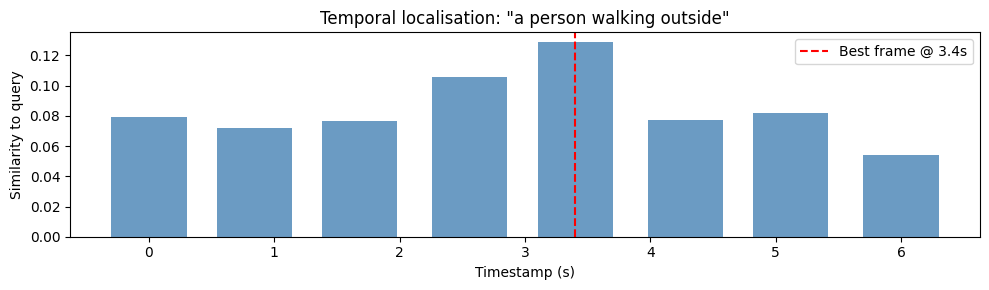

Most relevant timestamp: 3.4s


In [6]:
import matplotlib.pyplot as plt

def localize(query_text, embed_path):
    """Score each frame against the query to find the most relevant timestamp."""
    data         = torch.load(embed_path, map_location='cpu', weights_only=False)
    frame_embeds = data['visual_embeds'].to(device).float()   # (8, 768)
    timestamps   = data['timestamps']

    q_t = torch.tensor(encode_query(query_text)).to(device)   # (1, 512)

    with torch.no_grad(), torch.amp.autocast('cuda'):
        frame_proj = model.video_proj(frame_embeds)           # (8, 512)
        frame_proj = F.normalize(frame_proj, dim=-1)

    scores = (frame_proj @ q_t.T).squeeze(-1).cpu().numpy()   # (8,)
    best_t = timestamps[int(np.argmax(scores))]

    plt.figure(figsize=(10, 3))
    bar_width = max(timestamps) / len(timestamps) * 0.8 if len(timestamps) > 1 else 0.5
    plt.bar(timestamps, scores, width=bar_width, color='steelblue', alpha=0.8)
    plt.axvline(best_t, color='red', linestyle='--', label=f'Best frame @ {best_t:.1f}s')
    plt.xlabel('Timestamp (s)'); plt.ylabel('Similarity to query')
    plt.title(f'Temporal localisation: "{query_text}"')
    plt.legend(); plt.tight_layout(); plt.show()
    return best_t


# Build a combined record lookup across both test manifests for embed_path lookup
all_records = []
for mp in TEST_MANIFESTS:
    if os.path.exists(mp):
        with open(mp) as f:
            all_records += json.load(f)

# Use the top retrieval result from the last built index
example_query = 'a person walking outside'
top           = search(example_query, top_k=1)[0]
embed_path    = next(r['embed_path'] for r in all_records
                     if r['video_id'] == top['video_id'])

print(f'Top result: {top["video_id"]}  score={top["score"]:.4f}')
best_t = localize(example_query, embed_path)
print(f'Most relevant timestamp: {best_t:.1f}s')
